# Import Libraries

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

from sklearn import linear_model
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, r2_score

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/Housing.csv


# EDA

In [2]:
data = pd.read_csv('/kaggle/input/Housing.csv')
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
data.info() # General structure view

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
data.isnull().sum() # NaN values

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [5]:
print(data.duplicated().sum()) # Duplicated observations

0


<Figure size 800x600 with 0 Axes>

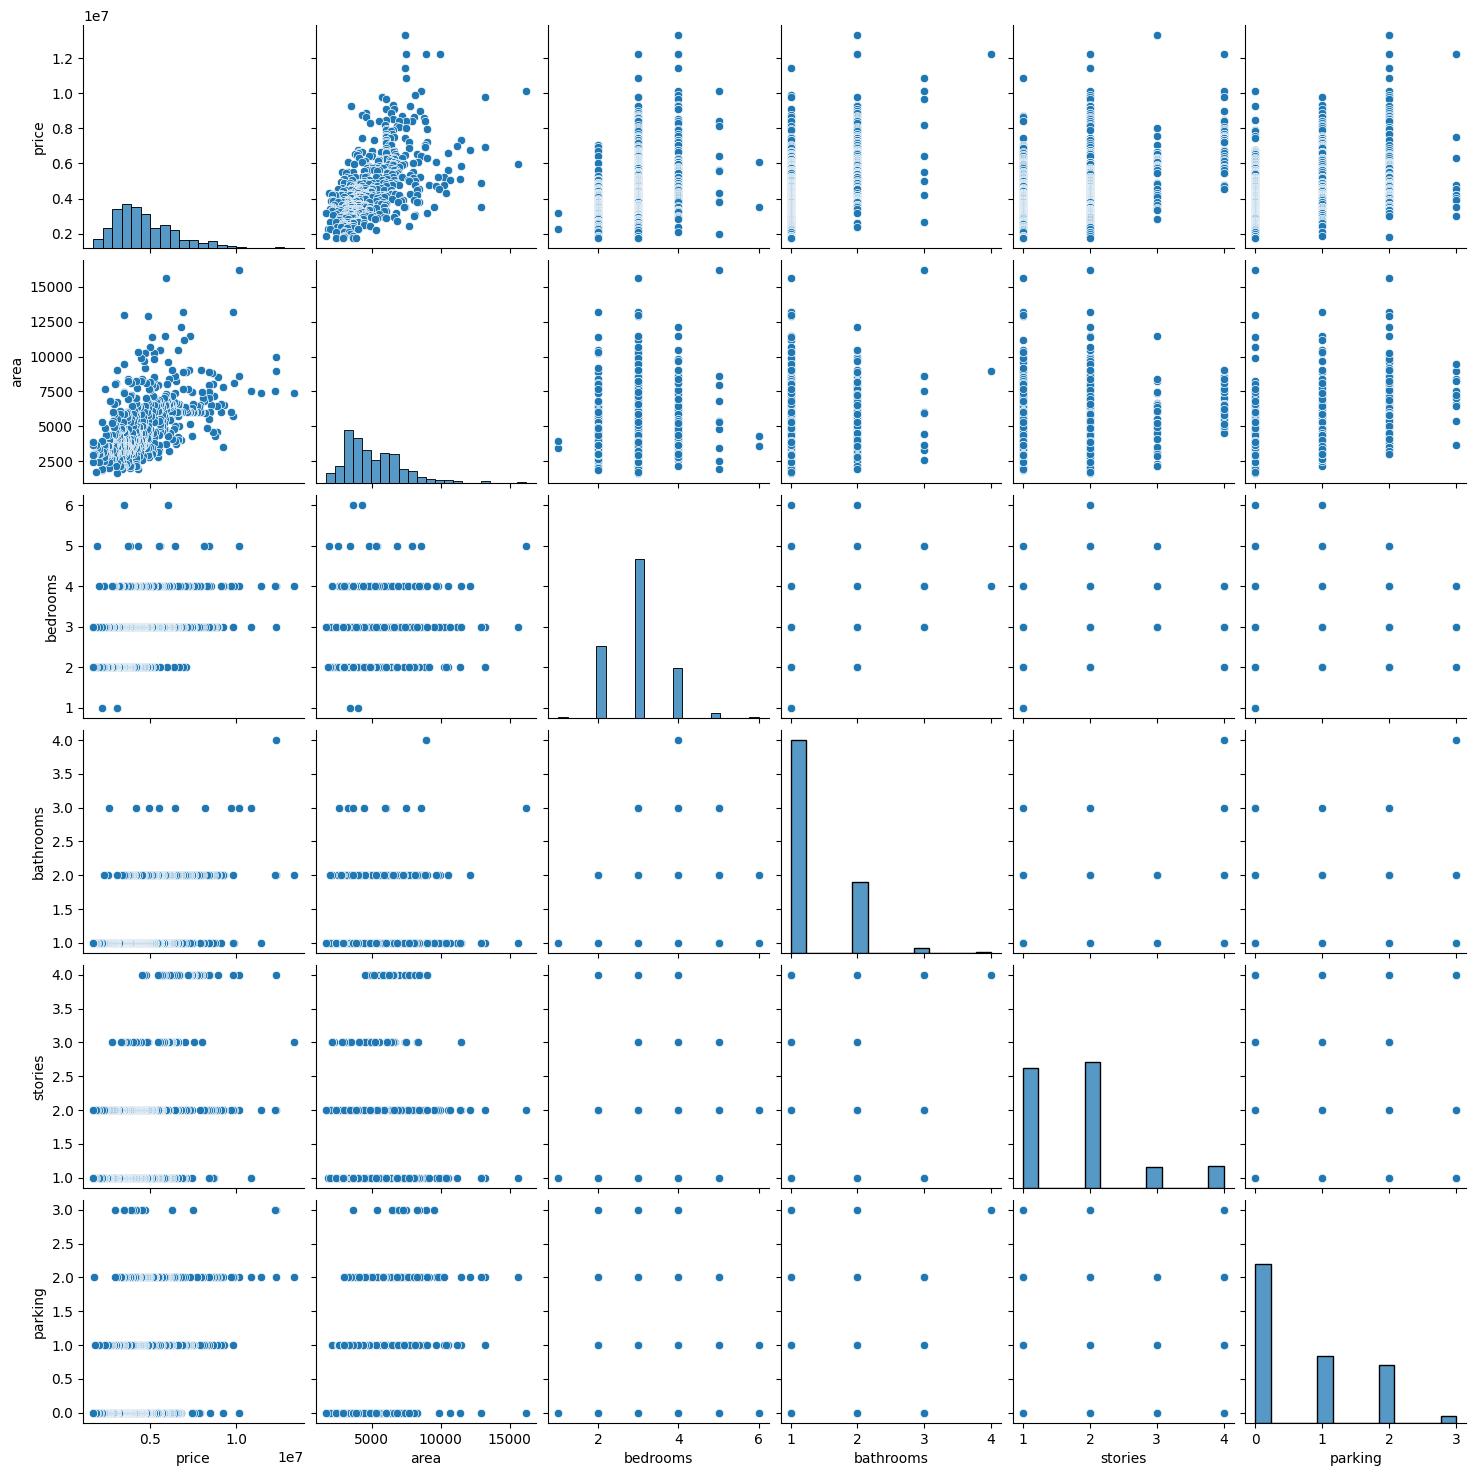

In [6]:
plt.figure(figsize = (8, 6))
sns.pairplot(data)
plt.grid(True)
plt.show()

In [7]:
non_numeric_cols = data.select_dtypes(exclude = ['number']).columns
print("Non-numeric columns: ")
print(list(non_numeric_cols))

Non-numeric columns: 
['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


The dataset only need to be encoded

Non-numeric columns need to be encoded cause computers only understand numbers

In [8]:
for col in non_numeric_cols:
    print(f"Unique values in '{col}': ")
    print(data[col].unique())
    print("-" * 40)

Unique values in 'mainroad': 
['yes' 'no']
----------------------------------------
Unique values in 'guestroom': 
['no' 'yes']
----------------------------------------
Unique values in 'basement': 
['no' 'yes']
----------------------------------------
Unique values in 'hotwaterheating': 
['no' 'yes']
----------------------------------------
Unique values in 'airconditioning': 
['yes' 'no']
----------------------------------------
Unique values in 'prefarea': 
['yes' 'no']
----------------------------------------
Unique values in 'furnishingstatus': 
['furnished' 'semi-furnished' 'unfurnished']
----------------------------------------


# Preprocessing

Data split should be done before being encoded

In [9]:
X = data.drop(["price"], axis = 1)
Y = data["price"]
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [10]:
bin_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
or_cols = ['furnishingstatus']

# Build transform process with ColumnTransformer
preprocessing = ColumnTransformer(
    transformers = [('binary_step', OrdinalEncoder(), bin_cols), 
                ('multi_step', OneHotEncoder(drop = 'first', sparse_output = False, dtype = int), or_cols)],
    remainder = 'passthrough'
)

train_arr_encoded = preprocessing.fit_transform(x_train)
test_arr_encoded = preprocessing.transform(x_test)
feature_names = preprocessing.get_feature_names_out()

print(list(feature_names))

train_set_encoded = pd.DataFrame(train_arr_encoded, columns = feature_names)
test_set_encoded = pd.DataFrame(test_arr_encoded, columns = feature_names)

['binary_step__mainroad', 'binary_step__guestroom', 'binary_step__basement', 'binary_step__hotwaterheating', 'binary_step__airconditioning', 'binary_step__prefarea', 'multi_step__furnishingstatus_semi-furnished', 'multi_step__furnishingstatus_unfurnished', 'remainder__area', 'remainder__bedrooms', 'remainder__bathrooms', 'remainder__stories', 'remainder__parking']


In [11]:
train_set_encoded.head(10)

,binary_step__mainroad,binary_step__guestroom,binary_step__basement,binary_step__hotwaterheating,binary_step__airconditioning,binary_step__prefarea,multi_step__furnishingstatus_semi-furnished,multi_step__furnishingstatus_unfurnished,remainder__area,remainder__bedrooms,remainder__bathrooms,remainder__stories,remainder__parking
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,6000.0,3.0,2.0,4.0,1.0
1,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,7200.0,3.0,2.0,1.0,3.0
2,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,3816.0,2.0,1.0,1.0,2.0
3,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,2610.0,3.0,1.0,2.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3750.0,3.0,1.0,2.0,0.0
5,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,5010.0,3.0,1.0,2.0,0.0
6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3850.0,3.0,1.0,2.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5076.0,3.0,1.0,1.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3180.0,3.0,1.0,1.0,0.0
9,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6020.0,3.0,1.0,1.0,0.0


In [12]:
print("Train set overview:")
print(train_set_encoded.info())
print("-" * 80)
print("Train set overview:")
print(test_set_encoded.info())

Train set overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 13 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   binary_step__mainroad                        436 non-null    float64
 1   binary_step__guestroom                       436 non-null    float64
 2   binary_step__basement                        436 non-null    float64
 3   binary_step__hotwaterheating                 436 non-null    float64
 4   binary_step__airconditioning                 436 non-null    float64
 5   binary_step__prefarea                        436 non-null    float64
 6   multi_step__furnishingstatus_semi-furnished  436 non-null    float64
 7   multi_step__furnishingstatus_unfurnished     436 non-null    float64
 8   remainder__area                              436 non-null    float64
 9   remainder__bedrooms                          436 non-nul

In [13]:
kf = KFold(n_splits = 4, shuffle = True, random_state = 42)
deg = [1, 2, 3]
cv_results = {}

for d in deg:
    fold_rmse = []

    for train_index, val_index in kf.split(train_set_encoded):
        x_train_fold, x_val_fold = train_set_encoded.iloc[train_index], train_set_encoded.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        poly = PolynomialFeatures(degree = d)
        x_train_poly = poly.fit_transform(x_train_fold)
        x_val_poly = poly.transform(x_val_fold)

        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train_poly)
        x_val_scaled = scaler.transform(x_val_poly)

        regr = linear_model.LinearRegression()
        regr.fit(x_train_scaled, y_train_fold)

        y_val_pred = regr.predict(x_val_scaled)

        rmse = np.sqrt(np.mean((y_val_pred - y_val_fold)**2))
        fold_rmse.append(rmse)

    avg_rmse = np.mean(fold_rmse)
    cv_results[d] = avg_rmse

In [14]:
for d, rmse in cv_results.items():
    print(f"degree = {d}, RMSE = {rmse}")

# Choose the best d
best_d = min(cv_results, key = cv_results.get)
print(f"Best degree: {best_d}")

degree = 1, RMSE = 1025597.9183633291
degree = 2, RMSE = 1338135.5798956682
degree = 3, RMSE = 127426968.95041972
Best degree: 1


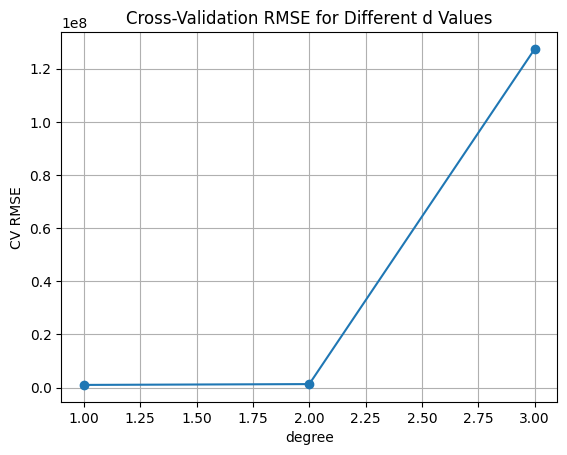

In [15]:
plt.plot(
    list(cv_results.keys()),
    list(cv_results.values()),
    marker="o"
)

plt.xlabel("degree")
plt.ylabel("CV RMSE")
plt.title("Cross-Validation RMSE for Different d Values")
plt.grid(True)
plt.show()

It is apparently seen that function with degree = 1 is the best fit

# Final train on full train_set

In [16]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(train_set_encoded)
x_test_scaled = scaler.transform(test_set_encoded)

regr = linear_model.LinearRegression()
regr.fit(x_train_scaled, y_train)

y_pred = regr.predict(x_test_scaled)
rmse = np.sqrt(np.mean((y_test - y_pred)**2))

print(rmse)

1324506.9600914402


# Evaluation

In [17]:
# y_test: Real price
# y_pred: Price predicted by model 

r2 = r2_score(y_test, y_pred)

print(f"R2 Score: {r2:.4f}")
print(f"Model can explain {r2 * 100:.2f}% variation of housing price")

R2 Score: 0.6529
Model can explain 65.29% variation of housing price


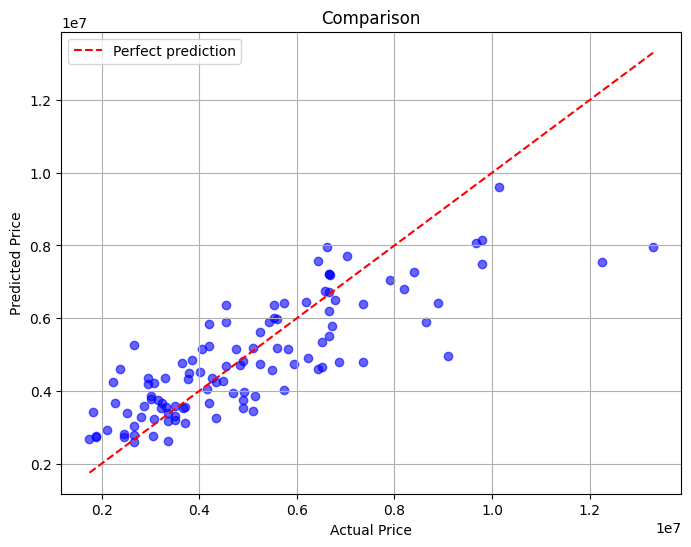

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect prediction')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Comparison")
plt.legend()
plt.grid(True)
plt.show()

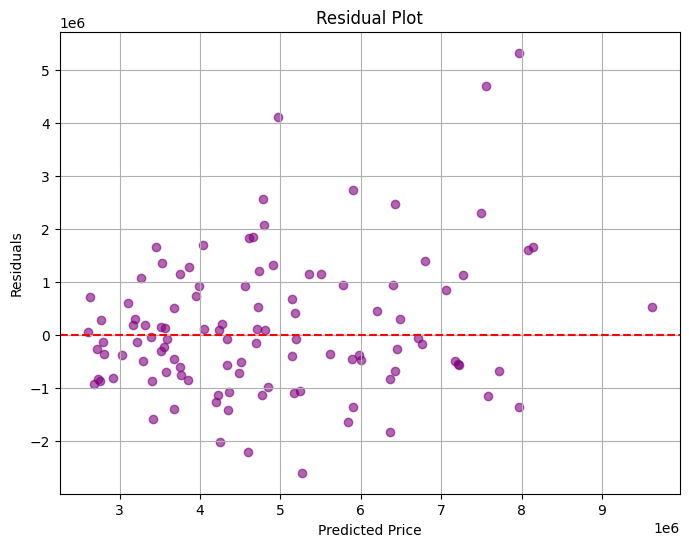

In [19]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--') # Zero-error-line

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()